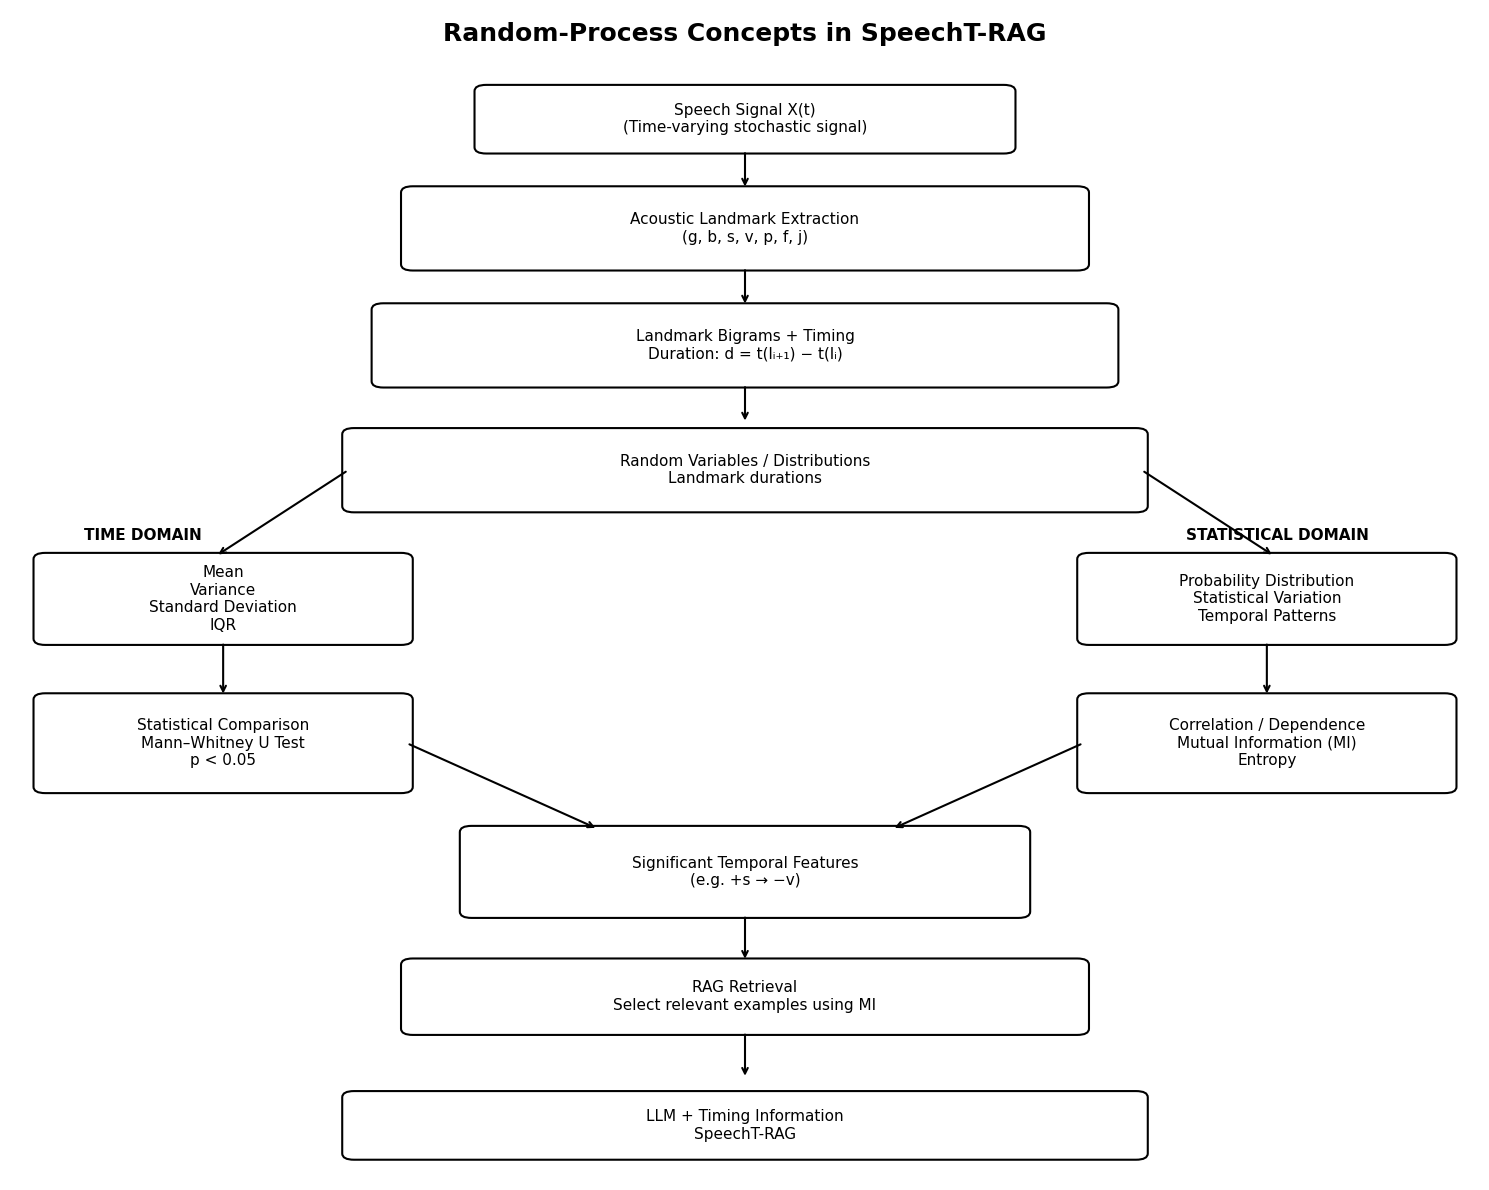

In [50]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(15, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 15)
ax.axis("off")

def box(x, y, w, h, text, fontsize=11):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        linewidth=1.5,
        facecolor="white"
    )
    ax.add_patch(patch)
    ax.text(
        x + w/2,
        y + h/2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )

def arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5
        )
    )

# Title
ax.text(
    5, 14.6,
    "Random-Process Concepts in SpeechT-RAG",
    ha="center",
    fontsize=18,
    fontweight="bold"
)

# Main flow

box(
    3.2, 13.2, 3.6, 0.8,
    "Speech Signal X(t)\n(Time-varying stochastic signal)"
)

arrow(5, 13.2, 5, 12.7)

box(
    2.7, 11.7, 4.6, 1.0,
    "Acoustic Landmark Extraction\n(g, b, s, v, p, f, j)"
)

arrow(5, 11.7, 5, 11.2)

box(
    2.5, 10.2, 5.0, 1.0,
    "Landmark Bigrams + Timing\nDuration: d = t(lᵢ₊₁) − t(lᵢ)"
)

arrow(5, 10.2, 5, 9.7)

box(
    2.3, 8.6, 5.4, 1.0,
    "Random Variables / Distributions\nLandmark durations"
)

# Statistical concepts branching

arrow(2.3, 9.1, 1.4, 8.0)
arrow(7.7, 9.1, 8.6, 8.0)

box(
    0.2, 6.9, 2.5, 1.1,
    "Mean\nVariance\nStandard Deviation\nIQR"
)

box(
    7.3, 6.9, 2.5, 1.1,
    "Probability Distribution\nStatistical Variation\nTemporal Patterns"
)

arrow(1.45, 6.9, 1.45, 6.2)
arrow(8.55, 6.9, 8.55, 6.2)

box(
    0.2, 5.0, 2.5, 1.2,
    "Statistical Comparison\nMann–Whitney U Test\np < 0.05"
)

box(
    7.3, 5.0, 2.5, 1.2,
    "Correlation / Dependence\nMutual Information (MI)\nEntropy"
)

# Middle concepts

arrow(2.7, 5.6, 4.0, 4.5)
arrow(7.3, 5.6, 6.0, 4.5)

box(
    3.1, 3.4, 3.8, 1.1,
    "Significant Temporal Features\n(e.g. +s → −v)"
)

arrow(5, 3.4, 5, 2.8)

box(
    2.7, 1.9, 4.6, 0.9,
    "RAG Retrieval\nSelect relevant examples using MI"
)

arrow(5, 1.9, 5, 1.3)

box(
    2.3, 0.3, 5.4, 0.8,
    "LLM + Timing Information\nSpeechT-RAG"
)

# Side labels
ax.text(
    0.5, 8.2,
    "TIME DOMAIN",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    8.0, 8.2,
    "STATISTICAL DOMAIN",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [1]:
!pip install librosa soundfile scipy matplotlib pandas numpy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from scipy import signal
from scipy.stats import norm

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [24]:
print("=" * 70)
print("        SPEECH RANDOM-PROCESS ANALYSIS")
print("        RESEARCH DEMONSTRATION ONLY")
print("=" * 70)

print("""
This notebook demonstrates random-process analysis of a speech signal.

The analysis includes:
1. Time-domain waveform
2. Mean
3. Variance
4. Standard deviation
5. Probability distribution
6. Autocorrelation
7. Power Spectral Density (PSD)

IMPORTANT:
This is an academic/research demonstration.
It is NOT a medical diagnosis.

The analysis does NOT determine whether the speaker is
healthy or has depression.
""")

print("=" * 70)

        SPEECH RANDOM-PROCESS ANALYSIS
        RESEARCH DEMONSTRATION ONLY

This notebook demonstrates random-process analysis of a speech signal.

The analysis includes:
1. Time-domain waveform
2. Mean
3. Variance
4. Standard deviation
5. Probability distribution
6. Autocorrelation
7. Power Spectral Density (PSD)

IMPORTANT:
This is an academic/research demonstration.
It is NOT a medical diagnosis.

The analysis does NOT determine whether the speaker is
healthy or has depression.



In [25]:
from google.colab import files

uploaded = files.upload()

audio_file = list(uploaded.keys())[0]

print("Loaded file:", audio_file)

Saving my_voice.m4a to my_voice (1).m4a
Loaded file: my_voice (1).m4a


In [26]:
audio, sr = librosa.load(audio_file, sr=None)

duration = len(audio) / sr

print("Sampling Rate :", sr, "Hz")
print("Number of Samples :", len(audio))
print("Duration :", round(duration, 2), "seconds")

Sampling Rate : 44100 Hz
Number of Samples : 204800
Duration : 4.64 seconds


/tmp/ipykernel_2186/2225809704.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_file, sr=None)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [27]:
time = np.arange(len(audio)) / sr

print("Time vector created.")
print("First 10 time values:")
print(time[:10])

Time vector created.
First 10 time values:
[0.00000000e+00 2.26757370e-05 4.53514739e-05 6.80272109e-05
 9.07029478e-05 1.13378685e-04 1.36054422e-04 1.58730159e-04
 1.81405896e-04 2.04081633e-04]


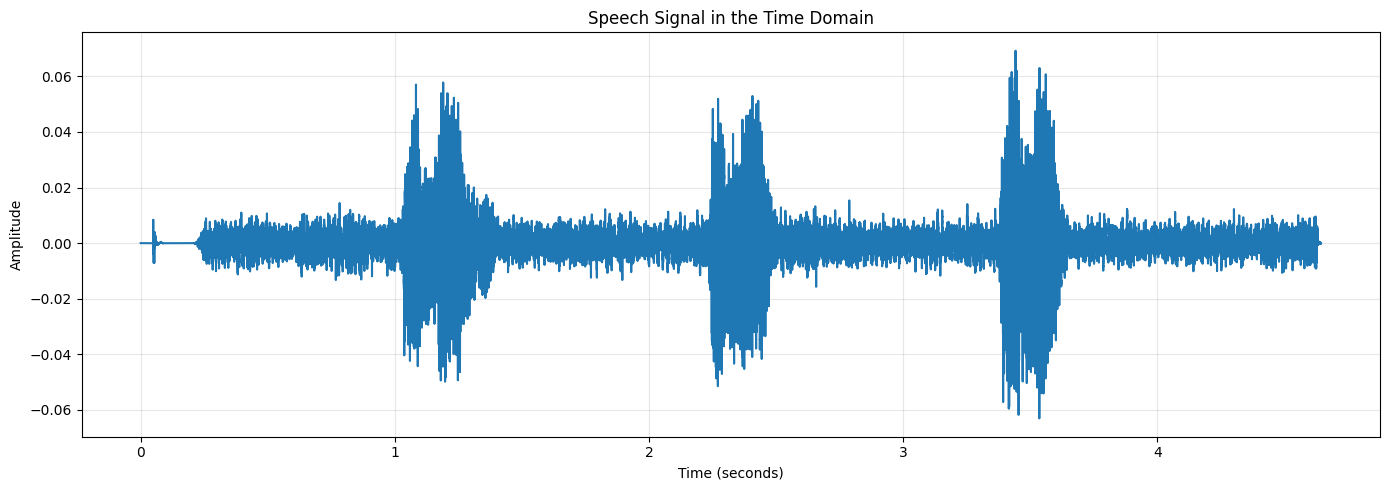

In [28]:
plt.figure(figsize=(14, 5))

plt.plot(time, audio)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.title("Speech Signal in the Time Domain")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# | Symbol | Simple meaning                     |
# | ------ | ---------------------------------- |
# | `g`    | vocal-fold vibration               |
# | `b`    | turbulent noise / burst-like event |
# | `s`    | syllabic/nasal event               |
# | `v`    | voiced frication                   |
# | `p`    | periodicity                        |
# | `f`    | unvoiced frication                 |
# | `j`    | sudden F0/pitch change             |


In [51]:
mean_value = np.mean(audio)

print("Mean amplitude =", mean_value)

Mean amplitude = -1.8790364e-07


In [52]:
variance_value = np.var(audio)
std_value = np.std(audio)

print("Variance =", variance_value)
print("Standard Deviation =", std_value)

Variance = 6.6600885e-05
Standard Deviation = 0.008160937


In [53]:
rms_value = np.sqrt(np.mean(audio**2))

print("RMS amplitude =", rms_value)

RMS amplitude = 0.008160938


In [54]:
results = pd.DataFrame({
    "Measure": [
        "Sampling Rate (Hz)",
        "Duration (seconds)",
        "Number of Samples",
        "Mean",
        "Variance",
        "Standard Deviation",
        "RMS Amplitude",
        "Maximum Amplitude",
        "Minimum Amplitude"
    ],

    "Value": [
        sr,
        duration,
        len(audio),
        mean_value,
        variance_value,
        std_value,
        rms_value,
        np.max(audio),
        np.min(audio)
    ]
})

results

,Measure,Value
0,Sampling Rate (Hz),4.410000e+04
1,Duration (seconds),4.643991e+00
2,Number of Samples,2.048000e+05
3,Mean,-1.879036e-07
4,Variance,6.660089e-05
5,Standard Deviation,8.160937e-03
6,RMS Amplitude,8.160938e-03
7,Maximum Amplitude,6.924438e-02
8,Minimum Amplitude,-6.304932e-02


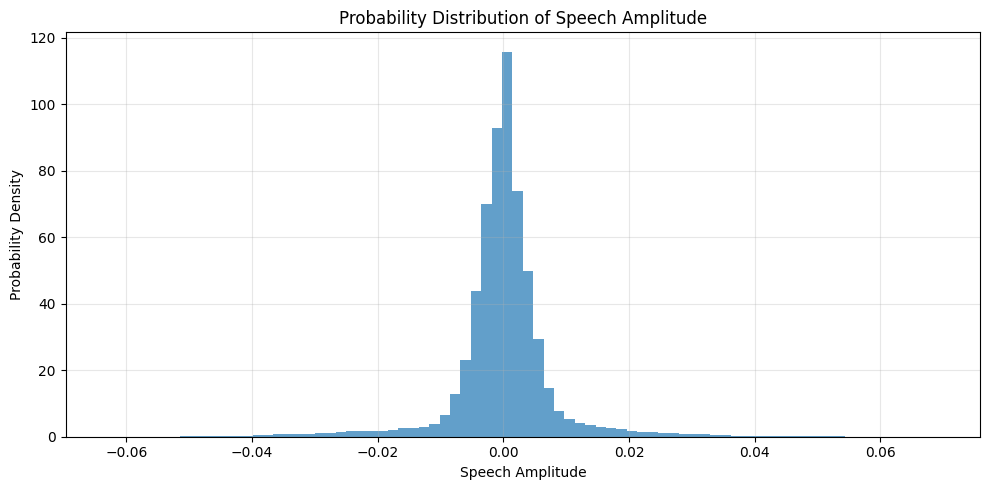

In [48]:
plt.figure(figsize=(10, 5))

plt.hist(
    audio,
    bins=80,
    density=True,
    alpha=0.7
)

plt.xlabel("Speech Amplitude")
plt.ylabel("Probability Density")

plt.title("Probability Distribution of Speech Amplitude")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

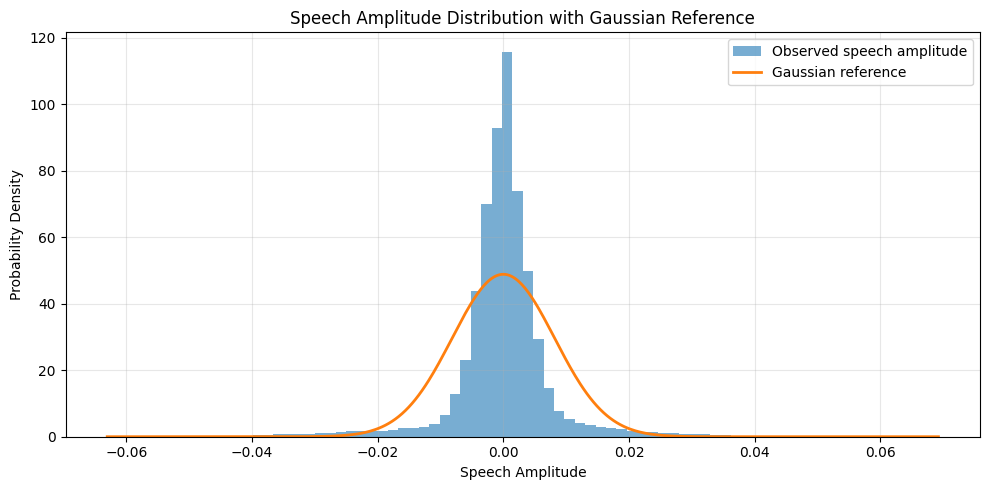

In [49]:
mu = np.mean(audio)
sigma = np.std(audio)

x = np.linspace(
    np.min(audio),
    np.max(audio),
    500
)

gaussian_curve = norm.pdf(
    x,
    mu,
    sigma
)

plt.figure(figsize=(10, 5))

plt.hist(
    audio,
    bins=80,
    density=True,
    alpha=0.6,
    label="Observed speech amplitude"
)

plt.plot(
    x,
    gaussian_curve,
    linewidth=2,
    label="Gaussian reference"
)

plt.xlabel("Speech Amplitude")
plt.ylabel("Probability Density")

plt.title(
    "Speech Amplitude Distribution with Gaussian Reference"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

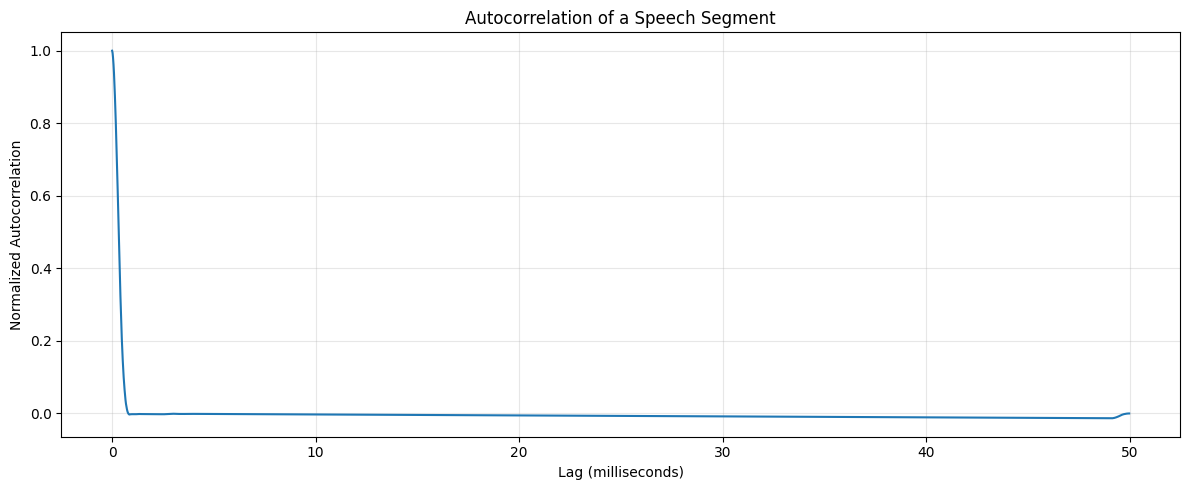

In [14]:
# Use first 0.05 seconds for a clear autocorrelation plot

segment_duration = 0.05

segment_length = int(segment_duration * sr)

segment = audio[:segment_length]

# Remove mean
segment = segment - np.mean(segment)

# Autocorrelation
autocorr = signal.correlate(
    segment,
    segment,
    mode="full"
)

lags = signal.correlation_lags(
    len(segment),
    len(segment),
    mode="full"
)

# Keep only positive lags
positive = lags >= 0

lags_positive = lags[positive]
autocorr_positive = autocorr[positive]

# Convert lag to milliseconds
time_lags = lags_positive / sr

# Normalize
autocorr_positive = (
    autocorr_positive / autocorr_positive[0]
)

plt.figure(figsize=(12, 5))

plt.plot(
    time_lags * 1000,
    autocorr_positive
)

plt.xlabel("Lag (milliseconds)")
plt.ylabel("Normalized Autocorrelation")

plt.title(
    "Autocorrelation of a Speech Segment"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Ignore lag = 0
if len(autocorr_positive) > 1:

    peak_index = np.argmax(
        autocorr_positive[1:]
    ) + 1

    peak_lag_ms = (
        time_lags[peak_index] * 1000
    )

    peak_value = autocorr_positive[peak_index]

    print(
        f"Strongest non-zero autocorrelation peak:"
    )

    print(
        f"Lag = {peak_lag_ms:.2f} ms"
    )

    print(
        f"Normalized autocorrelation = {peak_value:.4f}"
    )

Strongest non-zero autocorrelation peak:
Lag = 0.02 ms
Normalized autocorrelation = 0.9939


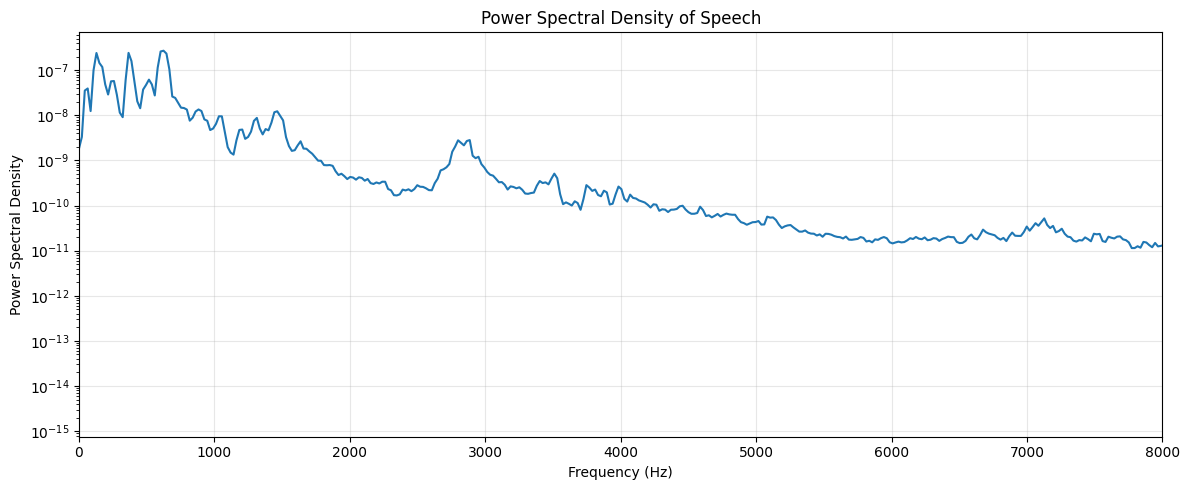

In [16]:
# Make sure nperseg isn't larger than the recording
nperseg = min(2048, len(audio))

frequencies, psd = signal.welch(
    audio,
    fs=sr,
    nperseg=nperseg
)

plt.figure(figsize=(12, 5))

plt.semilogy(
    frequencies,
    psd
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")

plt.title(
    "Power Spectral Density of Speech"
)

plt.xlim(
    0,
    min(8000, sr / 2)
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
dominant_index = np.argmax(psd)

dominant_frequency = frequencies[dominant_index]

print(
    "Dominant frequency component =",
    round(dominant_frequency, 2),
    "Hz"
)

Dominant frequency component = 624.46 Hz


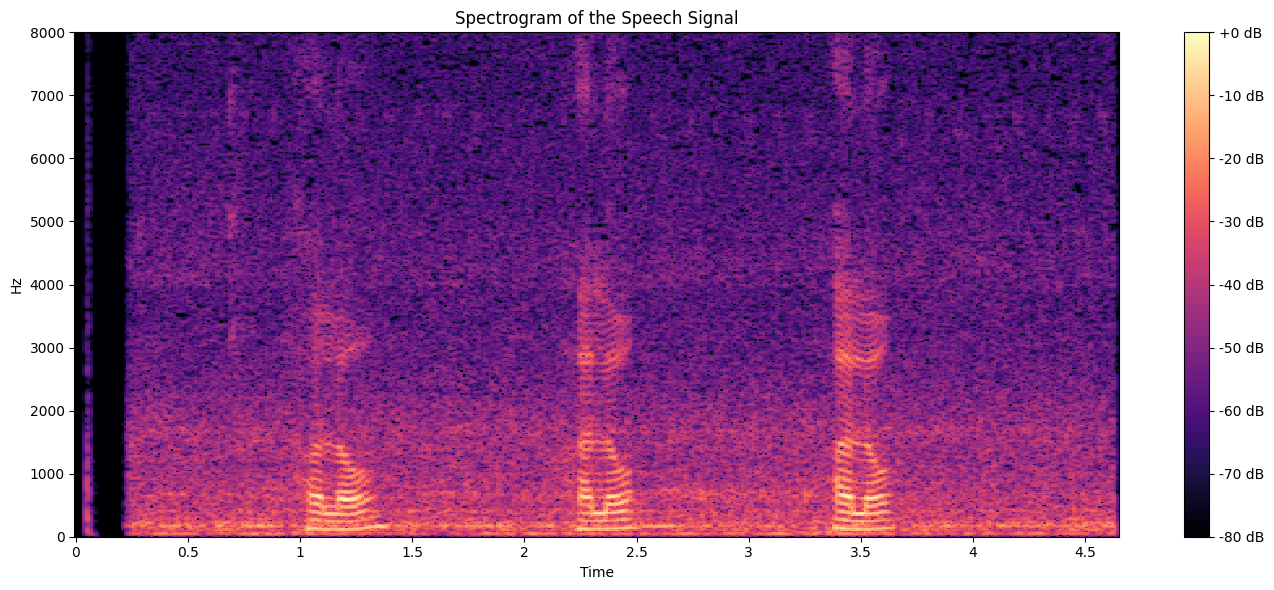

In [18]:
plt.figure(figsize=(14, 6))

D = librosa.amplitude_to_db(
    np.abs(
        librosa.stft(audio)
    ),
    ref=np.max
)

librosa.display.specshow(
    D,
    sr=sr,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.ylim(
    0,
    min(8000, sr / 2)
)

plt.title(
    "Spectrogram of the Speech Signal"
)

plt.tight_layout()
plt.show()

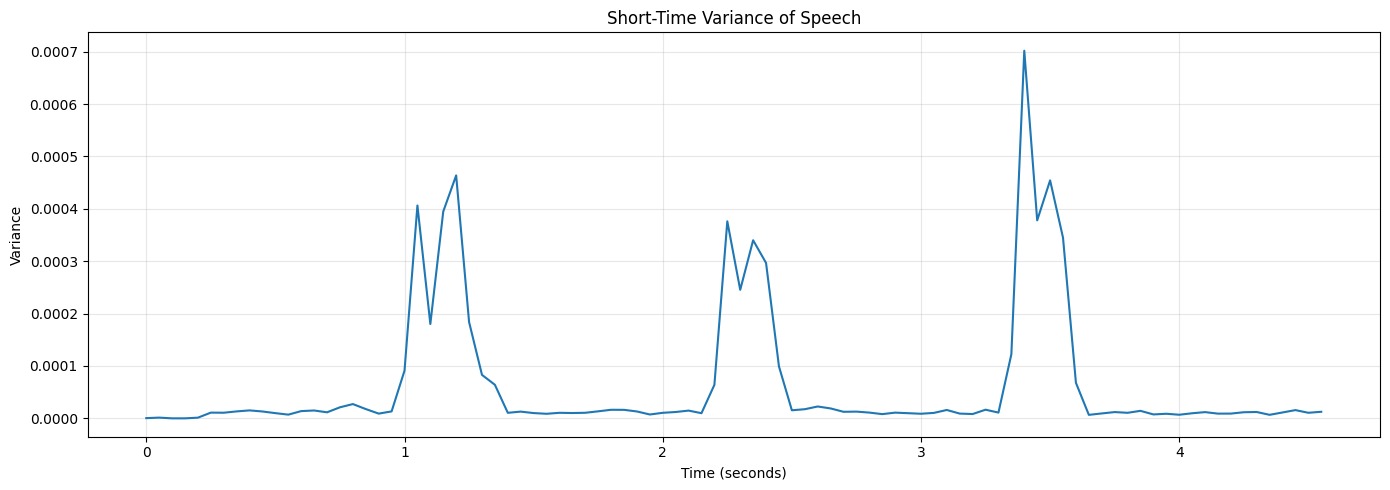

In [19]:
window_duration = 0.05  # 50 ms

window_size = int(
    window_duration * sr
)

variances = []
window_times = []

for start in range(
    0,
    len(audio) - window_size,
    window_size
):

    segment = audio[
        start:start + window_size
    ]

    variances.append(
        np.var(segment)
    )

    window_times.append(
        start / sr
    )

variances = np.array(variances)
window_times = np.array(window_times)

plt.figure(figsize=(14, 5))

plt.plot(
    window_times,
    variances
)

plt.xlabel("Time (seconds)")
plt.ylabel("Variance")

plt.title(
    "Short-Time Variance of Speech"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

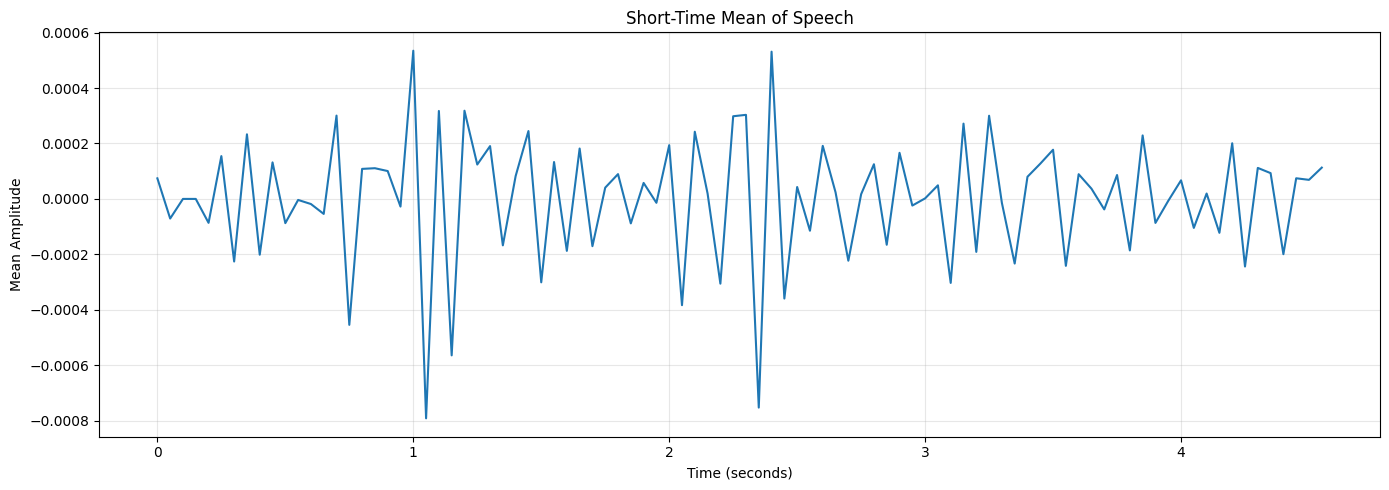

In [20]:
short_time_mean = []

for start in range(
    0,
    len(audio) - window_size,
    window_size
):

    segment = audio[
        start:start + window_size
    ]

    short_time_mean.append(
        np.mean(segment)
    )

short_time_mean = np.array(short_time_mean)

plt.figure(figsize=(14, 5))

plt.plot(
    window_times,
    short_time_mean
)

plt.xlabel("Time (seconds)")
plt.ylabel("Mean Amplitude")

plt.title(
    "Short-Time Mean of Speech"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
summary = pd.DataFrame({
    "Feature": [
        "Mean",
        "Variance",
        "Standard Deviation",
        "RMS",
        "Minimum Amplitude",
        "Maximum Amplitude",
        "Dominant Frequency (Hz)",
        "Strongest Non-Zero ACF Lag (ms)"
    ],

    "Value": [
        mean_value,
        variance_value,
        std_value,
        rms_value,
        np.min(audio),
        np.max(audio),
        dominant_frequency,
        peak_lag_ms
    ]
})

summary

,Feature,Value
0,Mean,-1.879036e-07
1,Variance,6.660089e-05
2,Standard Deviation,8.160937e-03
3,RMS,8.160938e-03
4,Minimum Amplitude,-6.304932e-02
5,Maximum Amplitude,6.924438e-02
6,Dominant Frequency (Hz),6.244629e+02
7,Strongest Non-Zero ACF Lag (ms),2.267574e-02


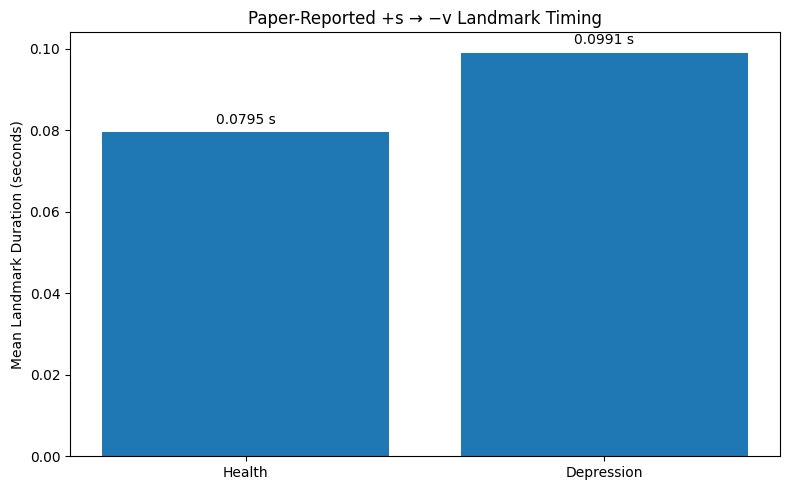

In [33]:
groups = [
    "Health",
    "Depression"
]

means = [
    0.0795,
    0.0991
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    groups,
    means
)

plt.ylabel(
    "Mean Landmark Duration (seconds)"
)

plt.title(
    "Paper-Reported +s → −v Landmark Timing"
)

for bar, value in zip(
    bars,
    means
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f"{value:.4f} s",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [23]:
print("=" * 60)
print("PAPER-REPORTED RESULT")
print("=" * 60)

print(
    "Health mean duration     : 0.0795 seconds"
)

print(
    "Depression mean duration : 0.0991 seconds"
)

print(
    "Mann–Whitney U p-value   : 0.00078"
)

print("=" * 60)

print("""
These values are reported results from the research paper.
They are NOT predictions generated from your recording.
""")

PAPER-REPORTED RESULT
Health mean duration     : 0.0795 seconds
Depression mean duration : 0.0991 seconds
Mann–Whitney U p-value   : 0.00078

These values are reported results from the research paper.
They are NOT predictions generated from your recording.



In [24]:
print("=" * 70)
print("              FINAL RESEARCH DEMONSTRATION")
print("=" * 70)

print("""
VOICE SIGNAL
     ↓
TIME-DOMAIN ANALYSIS
     ↓
Mean + Variance + Standard Deviation
     ↓
PROBABILITY DISTRIBUTION
     ↓
AUTOCORRELATION
     ↓
TEMPORAL STRUCTURE
     ↓
POWER SPECTRAL DENSITY
     ↓
FREQUENCY CHARACTERISTICS
     ↓
RANDOM-PROCESS INTERPRETATION
""")

print("=" * 70)

print("""
IMPORTANT DISCLAIMER

This notebook is an academic/research demonstration inspired
by the random-process concepts used in speech analysis research.

It does NOT diagnose depression.

No Healthy/Depression classification is performed on the speaker.

The numerical speech features describe this recording only and
should not be interpreted as evidence of a person's mental-health
condition.

Clinical depression can only be assessed by an appropriately
qualified healthcare professional.
""")

print("=" * 70)

              FINAL RESEARCH DEMONSTRATION

VOICE SIGNAL
     ↓
TIME-DOMAIN ANALYSIS
     ↓
Mean + Variance + Standard Deviation
     ↓
PROBABILITY DISTRIBUTION
     ↓
AUTOCORRELATION
     ↓
TEMPORAL STRUCTURE
     ↓
POWER SPECTRAL DENSITY
     ↓
FREQUENCY CHARACTERISTICS
     ↓
RANDOM-PROCESS INTERPRETATION


IMPORTANT DISCLAIMER

This notebook is an academic/research demonstration inspired
by the random-process concepts used in speech analysis research.

It does NOT diagnose depression.

No Healthy/Depression classification is performed on the speaker.

The numerical speech features describe this recording only and
should not be interpreted as evidence of a person's mental-health
condition.

Clinical depression can only be assessed by an appropriately
qualified healthcare professional.

